In [1]:
#Telecom customer churn analysis

In [2]:
#Import libraries
import pandas as pd
import numpy as np

In [3]:
#Load dataset
df=pd.read_csv("Telco_customer_churn_cleaned.csv")

In [4]:
#Data inspection

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TotalCharges
0,2171-UDMFD,Male,0,True,True,32,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,True,Credit card (automatic),19.45,False,674.55
1,8150-QUDFX,Male,0,False,False,2,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,19.85,False,51.60
2,7521-YXVZY,Male,0,False,True,3,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,19.95,False,58.30
3,5018-HEKFO,Female,0,False,False,10,True,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,True,Mailed check,24.50,False,270.15
4,4987-GQWPO,Male,0,False,False,17,False,No phone service,DSL,No,...,No,No,No,No,Month-to-month,False,Credit card (automatic),25.10,False,382.80


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   bool   
 4   Dependents        7043 non-null   bool   
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   bool   
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   bool   


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df.shape

(7043, 21)

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'Churn', 'TotalCharges'],
      dtype='object')

In [10]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner                bool
Dependents             bool
tenure                int64
PhoneService           bool
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling       bool
PaymentMethod        object
MonthlyCharges      float64
Churn                  bool
TotalCharges        float64
dtype: object

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
TotalCharges        11
dtype: int64

In [12]:
#Statistical analysis

In [13]:
from scipy.stats import ttest_ind, chi2_contingency

In [14]:
churn_yes = df[df["Churn"] == True]["MonthlyCharges"]
churn_no = df[df["Churn"] == False]["MonthlyCharges"]

In [15]:
#Null Hypothesis (H₀): The average monthly charges are the same for churned and non-churned customers.
#Alternative Hypothesis (H₁): The average monthly charges are different.
t_stat, p_value = ttest_ind(churn_yes, churn_no)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 16.53673801593629
P-value: 2.7066456068891876e-60


In [16]:
#conclusion
#There is a statistically significant difference in the average monthly charges between customers who churned and those who did not.

In [17]:
#Independent T-Test (Monthly Charges vs Churn):
#An independent t-test was conducted to compare the average monthly charges of churned and non-churned customers.
#The test produced a t-statistic of 16.537 and a p-value of 2.71 × 10⁻⁶⁰, which is far below the significance level of 0.05.
#Therefore, the null hypothesis was rejected, indicating a statistically significant difference in monthly charges between the two groups. 
#Customers who churned had significantly higher monthly charges than those who did not.

In [18]:
churn_yes = df[df["Churn"] == True]["tenure"]
churn_no = df[df["Churn"] == False]["tenure"]

In [19]:
#Null Hypothesis (H₀):The average tenure is the same for churned and non-churned customers.
#Alternative Hypothesis (H₁):The average tenure is different between the two groups.
t_stat, p_value = ttest_ind(churn_yes, churn_no)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -31.57955051135377
P-value: 7.99905796059022e-205


In [20]:
#Independent T-Test (Tenure vs Churn):
#An independent t-test was conducted to compare the average tenure of churned and non-churned customers.
#The test produced a t-statistic of -31.58 and a p-value of 7.999 × 10⁻²⁰⁵, which is significantly lower than 0.05.
#Therefore, the null hypothesis was rejected, indicating a statistically significant difference in tenure between the two groups.
#Customers who churned had significantly shorter tenure than customers who remained with the company.

In [21]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])
chi2, p_value, dof, expected = chi2_contingency(contract_churn)
print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 1184.5965720837926
P-value: 5.863038300673391e-258
Degrees of freedom: 2


In [22]:
#Chi-Square Test (Contract Type vs Churn)
#A Chi-Square Test of Independence was conducted to determine whether contract type is associated with customer churn. 
#The test produced a **Chi-square statistic of 1184.60**, a **p-value of 5.86 × 10⁻²⁵⁸**, and **2 degrees of freedom**. 
#Since the p-value is significantly lower than 0.05, the null hypothesis was rejected.
#This indicates a statistically significant association between contract type and customer churn.
#Customers with month-to-month contracts were significantly more likely to churn than customers with one-year or two-year contracts.

In [23]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"])
internet_churn

Churn,False,True
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [24]:
chi2, p_value, dof, expected = chi2_contingency(internet_churn)
print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 732.309589667794
P-value: 9.571788222840544e-160
Degrees of freedom: 2


In [25]:
# Chi-Square Test (Internet Service vs Churn)
# A Chi-Square Test of Independence was conducted to determine whether internet service type is associated with customer churn. 
#The test produced a **Chi-square statistic of 732.31**, a **p-value of 9.57 × 10⁻¹⁶⁰**, and **2 degrees of freedom**. 
#Since the p-value is significantly lower than 0.05, the null hypothesis was rejected. This indicates a statistically significant association between internet service type and customer churn.
#Customers using fiber optic internet service showed a higher likelihood of churning compared to customers using DSL or no internet service.

In [26]:
#Data preprocessing

In [27]:
df.duplicated().sum()

0

In [28]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [29]:
df["TotalCharges"].isnull().sum()

0

In [30]:
df.select_dtypes(include='object').columns

Index(['customerID', 'gender', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'],
      dtype='object')

In [31]:
# Drop customerID as it is only a unique identifier
df = df.drop("customerID", axis=1)

In [32]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

StreamingTV
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, 

In [33]:
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns, dtype=int)

In [34]:
df.shape

(7043, 42)

In [35]:
#Machine learning

In [36]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 41)
(1409, 41)
(5634,)
(1409,)


In [40]:
#Logistic regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [41]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [43]:
y_pred = model.predict(X_test_scaled)
y_pred[:10]

array([ True, False, False,  True, False,  True, False, False, False,
       False])

In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [45]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

Accuracy: 0.8126330731014905
[[941  97]
 [167 204]]
              precision    recall  f1-score   support

       False       0.85      0.91      0.88      1038
        True       0.68      0.55      0.61       371

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



In [46]:
#Random forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [47]:
rf_pred = rf_model.predict(X_test)
rf_pred[:10]

array([ True, False, False, False, False, False, False, False, False,
       False])

In [48]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy:", rf_accuracy)

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.7963094393186657
[[946  92]
 [195 176]]
              precision    recall  f1-score   support

       False       0.83      0.91      0.87      1038
        True       0.66      0.47      0.55       371

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



### Model Comparison: Why Logistic Regression Outperformed Random Forest

Although Random Forest is often assumed to be the stronger model, Logistic Regression actually 
performed better here — not just on overall accuracy (81.3% vs. 79.6%), but more importantly on 
**recall for the churn class** (0.55 vs. 0.47). Recall matters more than accuracy in this case 
because churners make up only about 26% of the dataset — a model could reach high accuracy just 
by predicting "no churn" for almost everyone, while still missing most of the customers actually 
at risk of leaving.

For a business trying to prevent churn, it's more valuable to correctly flag more at-risk 
customers, even at the cost of some false positives, than to be overly cautious and miss 
customers who are about to leave. Logistic Regression's higher recall makes it the more 
business-useful model here, despite Random Forest's reputation as a generally more powerful 
algorithm.

In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
7,TotalCharges,0.168532
3,tenure,0.146058
6,MonthlyCharges,0.144357
34,Contract_Month-to-month,0.054149
25,TechSupport_No,0.033144
16,OnlineSecurity_No,0.030529
39,PaymentMethod_Electronic check,0.028339
5,PaperlessBilling,0.024742
14,InternetService_Fiber optic,0.023894
1,Partner,0.022936


### Note on Top Features: TotalCharges, Tenure, and MonthlyCharges

The top three features by importance — TotalCharges, tenure, and MonthlyCharges — are not fully 
independent of each other. TotalCharges is roughly the product of tenure and MonthlyCharges 
(a customer's total spend accumulates over their tenure at their monthly rate), so these features 
carry overlapping information rather than three separate signals. This is a form of 
multicollinearity, and while it doesn't invalidate the model, it's worth keeping in mind when 
interpreting "importance" — the model may be splitting credit across these three related features 
rather than any single one being uniquely predictive.

In [50]:
import matplotlib.pyplot as plt

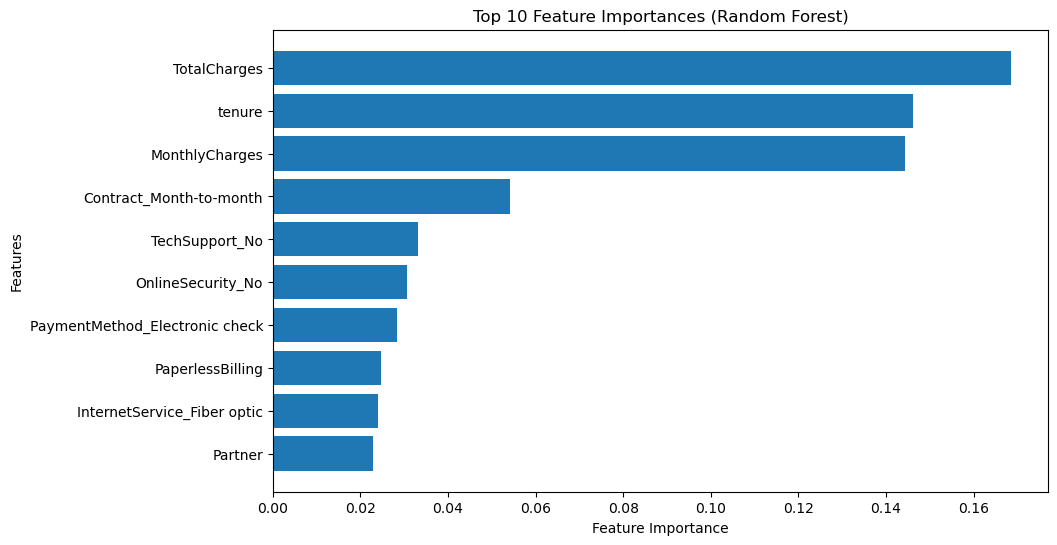

In [51]:
# Select top 10 important features
top_features = feature_importance.head(10)

# Create horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

## Key Findings Summary

- **Contract type is the strongest churn driver**: Month-to-month customers churn significantly 
  more than one-year or two-year contract customers (chi-square test, p < 0.001).
- **Fiber optic internet customers churn more** than DSL or no-internet customers 
  (chi-square test, p < 0.001).
- **Tenure and monthly charges both differ significantly** between churned and retained customers 
  (t-tests, p < 0.001): churned customers have shorter tenure and higher monthly charges on average.
- **Logistic Regression (81.3% accuracy, 0.55 recall on churners) outperformed Random Forest 
  (79.6% accuracy, 0.47 recall)** on the metric that matters most for this business problem — 
  correctly identifying at-risk customers, not just overall accuracy.
- **Top predictive features** were TotalCharges, tenure, and MonthlyCharges, though these overlap 
  significantly with each other; Contract type and TechSupport access were also strong, more 
  independent predictors.
- **Business recommendation**: Prioritize retention outreach toward month-to-month, fiber optic, 
  short-tenure customers with high monthly charges — this segment shows the clearest statistical 
  and predictive signal for churn risk.